---
title: "Wykład 4: Metoda gradientu prostego. Tensory w PyTorch"
subtitle: "Biblioteki Python w analizie danych"
author: "Tomasz Rodak"
---

## Optymalizacja metodą gradientu prostego

Załóżmy, że $L(\mathbf{w})$ jest funkcją straty dla modelu z parametrami $\mathbf{w}$. Funkcja $L$ zwraca nieujemną wartość reprezentującą stopień w jakim przewidywania modelu różnią się od rzeczywistych wartości. Typowe przykłady to:

**Błąd średniokwadratowy** (MSE) dla problemów regresji:
  
  \begin{equation*}
    L(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^N (y_i - f(\mathbf{x}_i, \mathbf{w}))^2
  \end{equation*}

gdzie $y_i$ to rzeczywista wartość, a $f(\mathbf{x}_i, \mathbf{w})$ to przewidywana wartość przez model dla danych wejściowych $\mathbf{x}_i$.

**Entropia krzyżowa** (*cross-entropy*) dla problemów klasyfikacji binarnej:

  \begin{equation*}
    L(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^N \left( y_i \log(f(\mathbf{x}_i, \mathbf{w})) + (1 - y_i) \log(1 - f(\mathbf{x}_i, \mathbf{w})) \right)
  \end{equation*}

gdzie $y_i$ to etykieta klasy (0 lub 1), a $f(\mathbf{x}_i, \mathbf{w})$ to przewidywane prawdopodobieństwo przynależności do klasy 1.

**Entropia krzyżowa** (*cross-entropy*) dla problemów klasyfikacji wieloklasowej:

  \begin{equation*}
    L(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^N \sum_{j=1}^K y_{ij} \log(f_j(\mathbf{x}_i, \mathbf{w}))
  \end{equation*}

gdzie $y_{ij}$ to etykieta klasy (1 jeśli próbka $i$ należy do klasy $j$, 0 w przeciwnym razie), a $f_j(\mathbf{x}_i, \mathbf{w})$ to przewidywane prawdopodobieństwo przynależności do klasy $j$.

Trening modelu polega na minimalizacji funkcji straty $L(\mathbf{w})$ względem parametrów $\mathbf{w}$. Metoda wykorzystywana do znalezienia minimum lokalnego funkcji $L(\mathbf{w})$ zależy przede wszystkim od tego, czy funkcja $L$ jest różniczkowalna względem $\mathbf{w}$, czy też nie:

- **Jeśli $L(\mathbf{w})$ jest różniczkowalna**, to zwykle korzysta się z jakiegoś wariantu metody gradientu prostego (o czym opowiemy za chwilę).
- **Jeśli $L(\mathbf{w})$ nie jest różniczkowalna**, lub informacja o gradientach nie jest dostępna, to stosuje się metody takie jak algorytmy ewolucyjne, optymalizację bayesowską, symulowane wyżarzanie, i wiele innych. 

Optymalizacja metodą gradientu prostego jest algorytmem iteracyjnym. Polega on na tym, że w pierwszym kroku wybieramy jakąś wartość początkową dla parametrów $\mathbf{w}^{(0)}$ (np. losowo), a następnie w każdym kroku $\tau$ aktualizujemy parametry $\mathbf{w}^{(\tau)}$ zgodnie z równaniem:

\begin{equation*}
  \mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau - 1)} + \left(\text{krok zależny od }\mathbf{w}^{(\tau - 1)}\right)
\end{equation*}

Wybór kroku zależnego od $\mathbf{w}^{(\tau - 1)}$ jest kluczowy dla działania algorytmu i właśnie w tym miejscu wykorzystuje się informację o gradiencie funkcji $L(\mathbf{w})$ w punkcie $\mathbf{w}^{(\tau - 1)}$.

### *Batch gradient descent*

Termin *batch* oznacza, że funkcję straty $L(\mathbf{w})$ będziemy obliczali na podstawie całego zbioru danych. Matematycznie *batch gradient descent* definiuje ciąg $\mathbf{w}^{(\tau)}$ wzorem indukcyjnym:

\begin{equation*}
\begin{aligned}
  \mathbf{w}^{(0)} &= \text{losowo ustalona początkowa wartość parametrów modelu} \\
  \mathbf{w}^{(\tau)} &= \mathbf{w}^{(\tau - 1)} - \eta \nabla_{\mathbf{w}} L(\mathbf{w}^{(\tau - 1)}),\quad \tau = 1, 2, \ldots
\end{aligned}
\end{equation*}

gdzie **współczynnik uczenia** (*learning rate*) $\eta>0$ jest hiperparametrem algorytmu.

#### Algorytm *Batch gradient descent*

**Wejście**: 

  * zbiór danych $\mathcal{D} = \{(\mathbf{x}_n, y_n)\}_{n=1}^N$,
  * funkcja straty $L(\mathbf{w})$ obliczana na podstawie całego zbioru danych $\mathcal{D}$
  * współczynnik uczenia $\eta>0$,
  * losowo inicjalizowana początkowa wartość parametrów modelu $\mathbf{w}$.

**Wyjście**:

  * parametry modelu $\mathbf{w}$ po zakończeniu treningu.

1. Powtarzaj:
   * $\mathbf{w} \gets \mathbf{w} - \eta \nabla_{\mathbf{w}} L(\mathbf{w})$.
2. aż do osiągnięcia zbieżności.
3. Zwróć $\mathbf{w}$.

### *Stochastic gradient descent* (SGD)

Funkcja straty $L(\mathbf{w})$ często daje się zapisać jako suma strat dla poszczególnych próbek:

\begin{equation*}
  L(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^N L_n(\mathbf{w}),
\end{equation*}

gdzie $L_n(\mathbf{w})$ to strata dla próbki $n$. Przykładowo, dla problemu regresji z funkcją straty MSE mamy:

\begin{equation*}
  L(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^N (y_n - f(\mathbf{x}_n, \mathbf{w}))^2 = \frac{1}{N} \sum_{n=1}^N L_n(\mathbf{w}),
\end{equation*}

gdzie $L_n(\mathbf{w}) = (y_n - f(\mathbf{x}_n, \mathbf{w}))^2$. Podobnie dla entropii krzyżowej mamy:

\begin{equation*}
  L(\mathbf{w}) = -\frac{1}{N} \sum_{n=1}^N\sum_{j=1}^K y_{nj} \log(f_j(\mathbf{x}_n, \mathbf{w})) = \frac{1}{N} \sum_{n=1}^N L_n(\mathbf{w}),
\end{equation*}

gdzie $L_n(\mathbf{w}) = -\sum_{j=1}^K y_{nj} \log(f_j(\mathbf{x}_n, \mathbf{w}))$. 

Jeśli $L(\mathbf{w})$ można zapisać jak wyżej, to gradient $\nabla_{\mathbf{w}} L(\mathbf{w})$ jest równy średniej z gradientów $L_n(\mathbf{w})$:

\begin{equation*}
  \nabla_{\mathbf{w}} L(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^N \nabla_{\mathbf{w}} L_n(\mathbf{w}).
\end{equation*}

Obserwacja ta jest wykorzystywana w algorytmie *stochastic gradient descent* (SGD), który polega na tym, że w każdym kroku aktualizujemy parametry $\mathbf{w}^{(\tau)}$ wykorzystując gradient tylko dla jednej próbki $n$ zamiast dla całego zbioru jak w przypadku *batch gradient descent*. Matematycznie SGD definiuje ciąg $\mathbf{w}^{(\tau)}$ wzorem indukcyjnym:

\begin{equation*}
\begin{aligned}
  \mathbf{w}^{(0)} &= \text{losowo ustalona początkowa wartość parametrów modelu} \\
  \mathbf{w}^{(\tau)} &= \mathbf{w}^{(\tau - 1)} - \eta \nabla_{\mathbf{w}} L_n(\mathbf{w}^{(\tau - 1)}),\quad \tau = 1, 2, \ldots
\end{aligned}
\end{equation*}
gdzie $n$ jest numerem próbki zależnym od kroku $\tau$.

#### Algorytm *Stochastic gradient descent* (SGD)

**Input**:

  * zbiór danych $\mathcal{D} = \{(\mathbf{x}_n, y_n)\}_{n=1}^N$,
  * funkcja straty $L_n(\mathbf{w})$ obliczana na podstawie próbki $n$,
  * współczynnik uczenia $\eta>0$,
  * losowo inicjalizowana początkowa wartość parametrów modelu $\mathbf{w}$.

**Output**:

  * parametry modelu $\mathbf{w}$ po zakończeniu treningu.

**Algorytm**:

1. $n \gets 1$.
2. Powtarzaj:
   * $\mathbf{w} \gets \mathbf{w} - \eta \nabla_{\mathbf{w}} L_n(\mathbf{w})$
   * $n \gets n + 1$
   * jeśli $n > N$, to:
     * wymieszaj dane $\mathcal{D}$,
     * $n \gets 1$.
3. aż do osiągnięcia zbieżności.
4. Zwróć $\mathbf{w}$.

Algorytm ten w ciągu $N$ kroków pętli wykona $N$ aktualizacji parametrów $\mathbf{w}$ przepuszczając przez model wszystkie próbki. Korzysta się z następującej terminologii:

* **iteracja** (*iteration*) — pojedyncza aktualizacja parametrów $\mathbf{w}$, czyli przetworzenie jednej próbki,
* **epoka** (*epoch*) — pełne przejście przez cały zbiór danych, czyli $N$ iteracji.

### *Mini-batch gradient descent*

*Mini-batch gradient descent* jest kompromisem pomiędzy *batch gradient descent* a SGD: aktualizacja parametrów $\mathbf{w}^{(\tau)}$ odbywa się na podstawie gradientu funkcji straty $L(\mathbf{w})$ obliczonego na podstawie *mini-batcha* próbek - podzbioru większego niż jedna próbka, ale mniejszego (zwykle znacznie) niż cały zbiór. 

Niech $B$ będzie liczbą próbek w *mini-batchu*. Jest to, podobnie jak $\eta$, hiperparametr algorytmu. Formalnie $B$ jest dowolną liczbą między 1 a $N$, w praktyce jest zazwyczaj ustalane jako jakaś potęga 2. Możemy teraz dokonać uogólnienia wzoru z paragrafu o SGD:

\begin{equation*}
\begin{split}
  L(\mathbf{w}) &= \frac{1}{N} \sum_{n=1}^N L_n(\mathbf{w}) 
  = \frac{B}{N} \sum_{k=1}^{N/B} \frac{1}{B} \sum_{j=1}^B L_{(k-1)B + j}(\mathbf{w})\\
  &= \frac{B}{N} \sum_{k=1}^{N/B} L_{(k-1)B + 1, (k-1)B + 2, \ldots, kB}(\mathbf{w}),
\end{split}
\end{equation*}

gdzie $L_{(k-1)B + 1, (k-1)B + 2, \ldots, kB}(\mathbf{w})$ to strata dla próbek z *mini-batcha* o numerach od $(k-1)B + 1$ do $kB$. W każdym kroku aktualizujemy parametry $\mathbf{w}^{(\tau)}$ wykorzystując gradient obliczony na batchu $B$ próbek.

Matematycznie:

\begin{equation*}
\begin{aligned}
  \mathbf{w}^{(0)} &= \text{losowo ustalona początkowa wartość parametrów modelu} \\
  \mathbf{w}^{(\tau)} &= \mathbf{w}^{(\tau - 1)} - \eta \nabla_{\mathbf{w}} L_{n_1, n_2, \ldots, n_B}(\mathbf{w}^{(\tau - 1)}),\quad \tau = 1, 2, \ldots
\end{aligned}
\end{equation*}

gdzie $n_1, n_2, \ldots, n_B$ to numery próbek w *mini-batchu* zależne od kroku $\tau$.

#### Algorytm *Mini-batch gradient descent*

**Input**:

  * zbiór danych $\mathcal{D} = \{(\mathbf{x}_n, y_n)\}_{n=1}^N$,
  * funkcja straty $L_{n:n+B}(\mathbf{w})$ obliczana na podstawie próbek $n:n+B$,
  * współczynnik uczenia $\eta>0$,
  * rozmiar *mini-batcha* $B$,
  * losowo inicjalizowana początkowa wartość parametrów modelu $\mathbf{w}$.

**Output**:

  * parametry modelu $\mathbf{w}$ po zakończeniu treningu.

**Algorytm**:

1. $n \gets 1$.
2. Powtarzaj:
   * $\mathbf{w} \gets \mathbf{w} - \eta \nabla_{\mathbf{w}} L_{n:n+B}(\mathbf{w})$
   * $n \gets n + B$
   * jeśli $n > N$, to:
     * wymieszaj dane $\mathcal{D}$,
     * $n \gets 1$.
3. aż do osiągnięcia zbieżności.
4. Zwróć $\mathbf{w}$.

W tym algorytmie **iteracja** to przetworzenie *mini-batcha* $B$ próbek, a **epoka** to, tak jak poprzednio, pełne przejście przez cały zbiór danych, czyli $N/B$ iteracji. 

Wyżej założyliśmy dla uproszczenia, że $N$ jest podzielne przez $B$. Jeśli tak nie jest, to w ostatniej iteracji po prostu przetwarzamy wszystkie pozostałe próbki, które nie zmieściły się w pełnych *mini-batchach*. 

## Tensory w PyTorch

Na wykładzie 1 poznaliśmy tablice NumPy (`np.ndarray`) — wielowymiarowe tablice liczb, na których można wykonywać zwektoryzowane operacje. **Tensor** w PyTorch (`torch.Tensor`) to ten sam pomysł — wielowymiarowa tablica wartości numerycznych — ale z dodatkową infrastrukturą zaprojektowaną pod trening modeli uczenia maszynowego. Na tym wykładzie interesuje nas przede wszystkim to, że tensory pozwalają nam pisać kod w stylu bardzo zbliżonym do NumPy, a jednocześnie korzystać z narzędzi PyTorch takich jak `DataLoader`. Na kolejnym wykładzie zobaczymy drugą kluczową cechę tensorów: mechanizm *różniczkowania automatycznego*, który pozwala PyTorchowi samodzielnie obliczać gradienty.

### Tworzenie tensorów

Tworzenie tensorów wygląda znajomo:

```python
import torch

# Z listy Pythona
a = torch.tensor([1.0, 2.0, 3.0])

# Odpowiedniki np.zeros, np.ones, np.rand
z = torch.zeros(3, 4)
o = torch.ones(2, 3)
r = torch.rand(2, 3)       # U(0,1)
rn = torch.randn(2, 3)     # N(0,1)

# Z tablicy NumPy
import numpy as np
arr = np.array([1.0, 2.0, 3.0])
t = torch.from_numpy(arr)   # współdzieli pamięć z arr!
t2 = torch.tensor(arr)      # kopia
```

### Typy danych

Domyślny typ zmiennoprzecinkowy to `torch.float32` (w NumPy: `np.float64`). Jest to różnica, do której warto się przyzwyczaić — modele uczenia maszynowego zwykle pracują w pojedynczej precyzji.

```python
x = torch.tensor([1, 2, 3])       # torch.int64
y = torch.tensor([1.0, 2.0, 3.0]) # torch.float32
z = torch.tensor([1.0, 2.0], dtype=torch.float64) # jawnie float64
```

### NumPy a PyTorch — podręczna ściągawka

| Operacja | NumPy | PyTorch |
|---|---|---|
| Tworzenie z listy | `np.array([1,2,3])` | `torch.tensor([1,2,3])` |
| Zera / jedynki | `np.zeros((2,3))` | `torch.zeros(2,3)` |
| Kształt | `a.shape` | `t.shape` (lub `t.size()`) |
| Zmiana kształtu | `a.reshape(2,3)` | `t.reshape(2,3)` (lub `t.view(2,3)`) |
| Transpozycja | `a.T` | `t.T` (lub `t.t()` dla 2D) |
| Łączenie | `np.concatenate` | `torch.cat` |
| Mnożenie macierzowe | `a @ b` | `t @ u` (lub `torch.matmul`) |
| Suma po osi | `a.sum(axis=0)` | `t.sum(dim=0)` |

Warto zapamiętać dwie różnice terminologiczne: w PyTorch oś nazywa się `dim` (nie `axis`), a zmiana kształtu bez kopiowania danych to `view` (nie ma odpowiednika w NumPy — `reshape` w NumPy *może* zwrócić widok, ale nie gwarantuje tego).

### Konwersja między NumPy i PyTorch

```python
# NumPy → PyTorch
t = torch.from_numpy(arr)     # widok — współdzieli pamięć
t = torch.tensor(arr)          # kopia

# PyTorch → NumPy
arr = t.numpy()                # widok (tylko dla tensorów na CPU)
```

`torch.from_numpy` tworzy widok na te same dane, więc zmiana w jednym obiekcie zmieni drugi. Jeśli potrzebujemy niezależnej kopii, używamy `torch.tensor(arr)`.

## `TensorDataset` i `DataLoader`

W pseudokodzie mini-batch gradient descent ręcznie dzieliliśmy dane na batche i w każdej epoce na nowo je mieszaliśmy. PyTorch automatyzuje ten wzorzec za pomocą dwóch klas:

- **`TensorDataset`** — owija tensory danych (cechy i etykiety) w obiekt, z którego można pobierać próbki po indeksie.
- **`DataLoader`** — przyjmuje `TensorDataset` (lub inny zbiór) i tworzy iterator, który w każdej epoce dzieli dane na mini-batche, opcjonalnie je mieszając.

```python
from torch.utils.data import TensorDataset, DataLoader

# Przykładowe dane: 100 próbek, 3 cechy
X = torch.randn(100, 3)
y = torch.randn(100, 1)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
```

Iteracja po `loader` w naturalny sposób realizuje schemat znany z pseudokodu:

```python
for epoch in range(num_epochs):
    for X_batch, y_batch in loader:    # mini-batche
        # X_batch.shape == (16, 3)  — dla pełnych batchy
        # y_batch.shape == (16, 1)
        ...
```

`DataLoader` automatycznie zajmuje się:

- podziałem danych na mini-batche o zadanym rozmiarze,
- losowym mieszaniem kolejności próbek na początku każdej epoki (gdy `shuffle=True`),
- obsługą ostatniego, niepełnego mini-batcha (domyślnie jest on krótszy; parametr `drop_last=True` pozwala go pominąć).

## Przykład: regresja liniowa metodą mini-batch gradient descent

Połączmy wszystkie elementy wykładu: zdefiniujemy model regresji liniowej, wyprowadzimy analitycznie gradient funkcji straty MSE, a następnie zaimplementujemy pętlę treningową z użyciem tensorów PyTorch i `DataLoader`.

### Model

Rozważamy model liniowy z wyrazem wolnym:

\begin{equation*}
  f(\mathbf{x}, \mathbf{w}) = w_0 + w_1 x_1 + \ldots + w_d x_d = \mathbf{x}^T \mathbf{w},
\end{equation*}

gdzie stosujemy konwencję, że $x_0 = 1$ (kolumna jedynek dołączona do danych), więc $\mathbf{w} = (w_0, w_1, \ldots, w_d)^T$.

### Funkcja straty

Funkcja straty MSE dla całego zbioru $N$ próbek:

\begin{equation*}
  L(\mathbf{w}) = \frac{1}{N} \|\mathbf{y} - X\mathbf{w}\|^2 = \frac{1}{N} (\mathbf{y} - X\mathbf{w})^T (\mathbf{y} - X\mathbf{w}),
\end{equation*}

gdzie $X \in \mathbb{R}^{N \times (d+1)}$ to macierz danych (z kolumną jedynek), a $\mathbf{y} \in \mathbb{R}^N$ to wektor etykiet.

### Gradient — wyprowadzenie

Obliczmy gradient $\nabla_{\mathbf{w}} L(\mathbf{w})$. Zaczniemy od rozwinięcia kwadratu normy. Niech $\mathbf{r} = \mathbf{y} - X\mathbf{w}$ będzie wektorem reszt (*residuals*). Wtedy:

\begin{equation*}
  L(\mathbf{w}) = \frac{1}{N} \mathbf{r}^T \mathbf{r} = \frac{1}{N} (\mathbf{y} - X\mathbf{w})^T (\mathbf{y} - X\mathbf{w}).
\end{equation*}

Rozwijając iloczyn:

\begin{equation*}
  L(\mathbf{w}) = \frac{1}{N} \left( \mathbf{y}^T\mathbf{y} - 2\mathbf{y}^T X\mathbf{w} + \mathbf{w}^T X^T X \mathbf{w} \right).
\end{equation*}

Różniczkując po $\mathbf{w}$:

\begin{equation*}
  \nabla_{\mathbf{w}} L(\mathbf{w}) = \frac{1}{N} \left( -2 X^T \mathbf{y} + 2 X^T X \mathbf{w} \right) = -\frac{2}{N} X^T (\mathbf{y} - X\mathbf{w}).
\end{equation*}

Dla mini-batcha $B$ próbek o indeksach $\{n_1, \ldots, n_B\}$ wzór przyjmuje identyczną postać, ale z podmacierzami $X_B$ i $\mathbf{y}_B$:

\begin{equation*}
  \nabla_{\mathbf{w}} L_B(\mathbf{w}) = -\frac{2}{B} X_B^T (\mathbf{y}_B - X_B \mathbf{w}).
\end{equation*}

### Implementacja

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

Wygenerujmy dane syntetyczne. Prawdziwa zależność to $y = 3 + 2x_1 - x_2 + \varepsilon$:

In [2]:
torch.manual_seed(42)
N = 200
d = 2

X_raw = torch.randn(N, d)
w_true = torch.tensor([3.0, 2.0, -1.0])  # w0=3, w1=2, w2=-1

# Dołączamy kolumnę jedynek (wyraz wolny)
X = torch.cat([torch.ones(N, 1), X_raw], dim=1)  # (N, d+1)
y = X @ w_true + 0.5 * torch.randn(N)            # (N,)

Przygotujmy `DataLoader`:

In [3]:
dataset = TensorDataset(X, y)
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Inicjalizujemy wagi losowo i uruchamiamy pętlę treningową:

In [4]:
w = torch.randn(d + 1)  # losowa inicjalizacja
eta = 0.05               # learning rate
num_epochs = 50

history = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    for X_batch, y_batch in loader:
        # Predykcja
        y_pred = X_batch @ w

        # Strata MSE na mini-batchu
        residuals = y_batch - y_pred
        loss = (residuals ** 2).mean()

        # Gradient — wzór analityczny
        grad = -2.0 / X_batch.shape[0] * (X_batch.T @ residuals)

        # Aktualizacja parametrów
        w = w - eta * grad

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoka {epoch+1:3d}/{num_epochs}, MSE: {avg_loss:.4f}")

Epoka  10/50, MSE: 0.2302
Epoka  20/50, MSE: 0.2256
Epoka  30/50, MSE: 0.2283
Epoka  40/50, MSE: 0.2279
Epoka  50/50, MSE: 0.2387


### Wyniki

Porównajmy wyuczone wagi z prawdziwymi:

In [5]:
print(f"Prawdziwe wagi:  {w_true.tolist()}")
print(f"Wyuczone wagi:   {[round(wi, 4) for wi in w.tolist()]}")

Prawdziwe wagi:  [3.0, 2.0, -1.0]
Wyuczone wagi:   [2.9541, 2.0085, -0.9647]


Wizualizacja spadku funkcji straty:

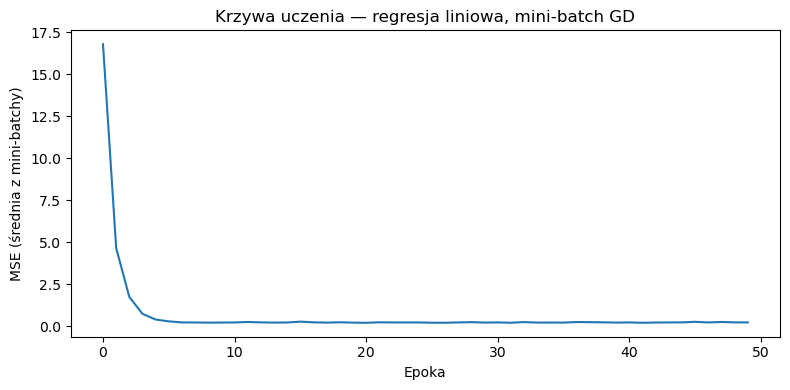

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history)
ax.set_xlabel("Epoka")
ax.set_ylabel("MSE (średnia z mini-batchy)")
ax.set_title("Krzywa uczenia — regresja liniowa, mini-batch GD");

### Dyskusja

Zwróćmy uwagę na kilka elementów tego przykładu.

**Ręczne obliczanie gradientu** — musieliśmy sami wyprowadzić wzór na $\nabla_{\mathbf{w}} L$ i zaprogramować go w linijce `grad = -2.0 / X_batch.shape[0] * (X_batch.T @ residuals)`. Dla regresji liniowej z MSE wzór jest prosty, ale dla bardziej złożonych modeli (sieci neuronowe, funkcje nieliniowe) wyprowadzanie gradientów ręcznie staje się niepraktyczne lub wręcz niemożliwe. Na następnym wykładzie poznamy mechanizm *różniczkowania automatycznego* (*autograd*) wbudowany w PyTorch, który zdejmie z nas ten obowiązek.

**Rola `DataLoader`** — bez niego musielibyśmy ręcznie implementować mieszanie danych i podział na batche, co jest dokładnie tym, co opisywaliśmy w pseudokodzie. `DataLoader` realizuje ten wzorzec automatycznie.

**Brak konwergencji do zera** — funkcja straty nie spada do zera, ponieważ dane zawierają szum ($\varepsilon$). Jest to zachowanie prawidłowe: model prawidłowo odzyskuje trend, ale nie może dopasować się do losowego szumu.